In [1]:
import nb_style
nb_style.apply()

In [50]:
# !pip install torch
# !pip install torchviz

In [51]:
!pip install psutil

**Workaround if the kernel dies during import:**


in command prompt run: 


<code>set KMP_DUPLICATE_LIB_OK=TRUE</code>

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

import numpy as np

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import time
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import psutil
import os

np.random.seed(42)
tf.random.set_seed(42)

Device: cpu


# load a scikit-learn regression dataset

For this example we use the diabetes dataset as provided by scikit-learn. The Scikit-learn diabetes dataset is a regression dataset with 442 samples and 10 medical features used to predict disease progression. 

More info on the dataset: 
<a href="https://www.geeksforgeeks.org/machine-learning/sklearn-diabetes-dataset/" target="_blank">
Sklearn Diabetes Dataset
</a>

Here we use <code>scaled=False</code> to load the unscaled feature values.

In [10]:
# Load data 
diabetes = load_diabetes(return_X_y=False,scaled=False)
Xpd = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
ypd = pd.Series(diabetes.target, name="target")

print("Xpd shape:", Xpd.shape)
print("ypd shape:", ypd.shape)

display(Xpd)

Xpd shape: (442, 10)
ypd shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,59.0,2.0,32.1,101.00,157.0,93.2,38.0,4.00,4.8598,87.0
1,48.0,1.0,21.6,87.00,183.0,103.2,70.0,3.00,3.8918,69.0
2,72.0,2.0,30.5,93.00,156.0,93.6,41.0,4.00,4.6728,85.0
3,24.0,1.0,25.3,84.00,198.0,131.4,40.0,5.00,4.8903,89.0
4,50.0,1.0,23.0,101.00,192.0,125.4,52.0,4.00,4.2905,80.0
...,...,...,...,...,...,...,...,...,...,...
437,60.0,2.0,28.2,112.00,185.0,113.8,42.0,4.00,4.9836,93.0
438,47.0,2.0,24.9,75.00,225.0,166.0,42.0,5.00,4.4427,102.0
439,60.0,2.0,24.9,99.67,162.0,106.6,43.0,3.77,4.1271,95.0
440,36.0,1.0,30.0,95.00,201.0,125.2,42.0,4.79,5.1299,85.0


Many regression algorithms including neural networks require scaled data to perform well. Thankfully, a scaled version of the diabetes dataset can be directly loaded by setting <code>scaled=True</code>. 

In [16]:
# Load data 
diabetes = load_diabetes(return_X_y=False,scaled=True)
Xpd = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
ypd = pd.Series(diabetes.target, name="target")

print("Xpd shape:", Xpd.shape)
print("ypd shape:", ypd.shape)

display(Xpd)

Xpd shape: (442, 10)
ypd shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


## Simple data analysis

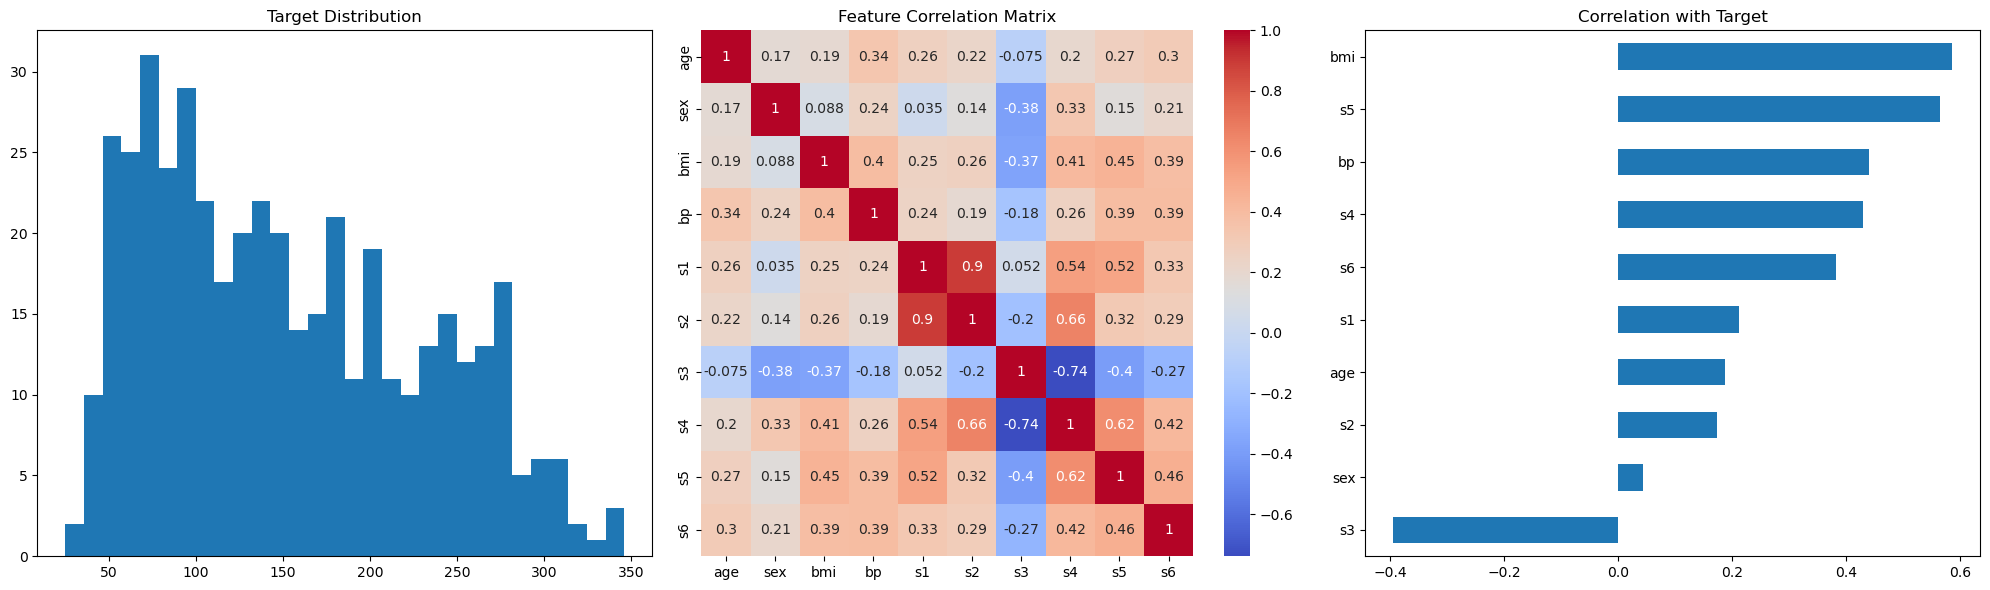

In [17]:
corr_target = Xpd.corrwith(ypd).sort_values()

fig, axes = plt.subplots(1, 3, figsize=(20,6))

# Histogram
axes[0].hist(ypd, bins=30)
axes[0].set_title("Target Distribution")

# Heatmap
sns.heatmap(Xpd.corr(), annot=True, cmap="coolwarm", ax=axes[1])
axes[1].set_title("Feature Correlation Matrix")

# Correlation with target (bar plot)
corr_target.plot(kind="barh", ax=axes[2])
axes[2].set_title("Correlation with Target")

plt.tight_layout()
plt.show()

In [46]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    Xpd, ypd, test_size=0.2, random_state=5
)

# # Standardize features 
# scaler = StandardScaler()
# X_train_np = scaler.fit_transform(X_train_np)
# X_test_np = scaler.transform(X_test_np)

print(X_train_np.shape, y_train_np.shape)

(353, 10) (353,)


# Build and train tensorflow model

In [19]:
keras_model = keras.Sequential([
    layers.Input(shape=(X_train_np.shape[1],)),
    layers.Dense(150, activation="relu"),
    layers.Dense(150, activation="relu"),
    layers.Dense(1)  # regression output
])

keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mae"
)

process = psutil.Process(os.getpid())
start_mem = process.memory_info().rss / 1024**2  # MB
start_time = time.time()

result = keras_model.fit(
    x=X_train_np, y=y_train_np,
    validation_data=(X_test_np,y_test_np),
    epochs=350,
    batch_size=16,
    verbose=1
)

end_time = time.time()
end_mem = process.memory_info().rss / 1024**2  # MB

y_train_np_hat=keras_model.predict(X_train_np)
y_test_np_hat=keras_model.predict(X_test_np)

print("Final val MAE:", result.history["val_loss"][-1])

Epoch 1/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 148.9405 - val_loss: 153.1359
Epoch 2/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 141.5891 - val_loss: 140.8234
Epoch 3/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 124.0458 - val_loss: 114.0969
Epoch 4/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 95.8102 - val_loss: 77.8435
Epoch 5/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 67.4978 - val_loss: 58.1022
Epoch 6/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55.9936 - val_loss: 56.5529
Epoch 7/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 51.7308 - val_loss: 52.0504
Epoch 8/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 49.7488 - val_loss: 49.6447
Epoch 9/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 47.6613 - val_loss: 47.8232
Epoch 10/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 46.4051 - val_loss: 46.8088
Epoch 11/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 45.4287 - val_loss: 46.5235
Epoch 12/350
23/23 ━━━━━━━━━━━━━━━

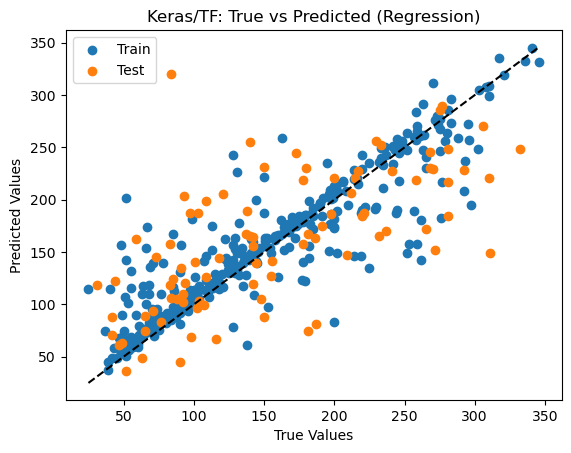

In [20]:
import matplotlib.pyplot as plt

# Perfect prediction line
min_val = min(y_test_np.min(), y_train_np.min())
max_val = max(y_test_np.max(), y_train_np.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--')

plt.scatter(y_train_np, y_train_np_hat, label="Train")
plt.scatter(y_test_np, y_test_np_hat, label="Test")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Keras/TF: True vs Predicted (Regression)")
plt.legend()
plt.show()

mae_train = mean_absolute_error(y_train_np, y_train_np_hat)
r2_train  = r2_score(y_train_np, y_train_np_hat)

mae_test = mean_absolute_error(y_test_np, y_test_np_hat)
r2_test  = r2_score(y_test_np, y_test_np_hat)


from IPython.display import display, HTML

html_output = f"""
<div style="
    border:2px solid #EDDFA4;
    padding:25px;
    border-radius:10px;
    background-color:#F0E7C2;
    width:200px;
    font-family:Arial;
">
    <h3 style="margin-top:0;"><b>Keras Results</b></h3>
    <b>Train MAE:</b> {mae_train:.2f} <br>
    <b>Train R2 :</b> {r2_train:.2f} <br><br>
    <b>Test MAE :</b> {mae_test:.2f} <br>
    <b>Test R2  :</b> {r2_test:.2f}
</div>
"""

display(HTML(html_output))

# Build and train pytorch model

In [47]:
# Convert to tensors
X_train_pt = torch.tensor(X_train.to_numpy(), dtype=torch.float32)
y_train_pt = torch.tensor(y_train.to_numpy(), dtype=torch.float32).view(-1, 1)

X_test_pt  = torch.tensor(X_test.to_numpy(), dtype=torch.float32)
y_test_pt  = torch.tensor(y_test.to_numpy(), dtype=torch.float32).view(-1, 1)

In [48]:
train_ds = TensorDataset(X_train_pt, y_train_pt)
test_ds  = TensorDataset(X_test_pt, y_test_pt)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)

In [36]:
train_ds[0]

(tensor([ 0.0817,  0.0507, -0.0256, -0.0367, -0.0704, -0.0464, -0.0397, -0.0026,
         -0.0412, -0.0052]),
 tensor([199.]))

In [37]:
for xb, yb in train_loader:
    print("Batch X shape:", xb.shape)
    print("Batch y shape:", yb.shape)
    print(xb[:2])   # first 2 samples in batch
    print(yb[:2])
    break

Batch X shape: torch.Size([16, 10])
Batch y shape: torch.Size([16, 1])
tensor([[ 0.0817,  0.0507, -0.0256, -0.0367, -0.0704, -0.0464, -0.0397, -0.0026,
         -0.0412, -0.0052],
        [ 0.0381,  0.0507,  0.0617,  0.0219, -0.0442, -0.0348, -0.0434, -0.0026,
          0.0199, -0.0176]])
tensor([[199.],
        [151.]])


In [38]:
len(train_loader)

23

In [39]:
torch_model = nn.Sequential(
    nn.Linear(X_train_pt.shape[1], 150),
    nn.ReLU(),
    nn.Linear(150, 150),
    nn.ReLU(),
    nn.Linear(150, 1)
).to(device)

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(torch_model.parameters(), lr=1e-3)

In [40]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

@torch.no_grad()
def predict(model, loader):
    model.eval()
    
    preds = []
    targets = []
    
    for xb, yb in loader:
        xb = xb.to(device)
        
        pred = model(xb)
        
        preds.append(pred.cpu())
        targets.append(yb)
    
    preds = torch.cat(preds).numpy().squeeze()
    targets = torch.cat(targets).numpy().squeeze()
    
    return preds, targets

In [41]:
processPT = psutil.Process(os.getpid())

start_memPT = processPT.memory_info().rss / 1024**2  # MB
start_timePT = time.time()
epochs = 350
for epoch in range(1, epochs + 1):
    loss = train_one_epoch(torch_model, train_loader)

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | train loss (MAE): {loss:.4f}")

end_timePT = time.time()
end_memPT = processPT.memory_info().rss / 1024**2  # MB

Epoch 020 | train loss (MAE): 51.7678
Epoch 040 | train loss (MAE): 45.4621
Epoch 060 | train loss (MAE): 43.4200
Epoch 080 | train loss (MAE): 42.7357
Epoch 100 | train loss (MAE): 42.3286
Epoch 120 | train loss (MAE): 42.0608
Epoch 140 | train loss (MAE): 41.8268
Epoch 160 | train loss (MAE): 41.6154
Epoch 180 | train loss (MAE): 41.4311
Epoch 200 | train loss (MAE): 41.2514
Epoch 220 | train loss (MAE): 41.1030
Epoch 240 | train loss (MAE): 40.9395
Epoch 260 | train loss (MAE): 40.7433
Epoch 280 | train loss (MAE): 40.5824
Epoch 300 | train loss (MAE): 40.3764
Epoch 320 | train loss (MAE): 40.1038
Epoch 340 | train loss (MAE): 39.8868


In [42]:
y_pred_train, y_true_train = predict(torch_model, train_loader)
y_pred_test,  y_true_test  = predict(torch_model, test_loader)

# Metrics train
mae_trainPT = mean_absolute_error(y_true_train, y_pred_train)
r2_trainPT  = r2_score(y_true_train, y_pred_train)

# Metrics test
mae_testPT = mean_absolute_error(y_true_test, y_pred_test)
r2_testPT  = r2_score(y_true_test, y_pred_test)

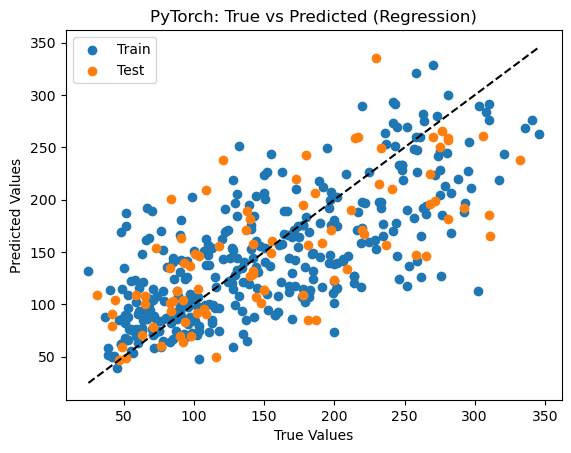

In [43]:
import matplotlib.pyplot as plt

# Perfect prediction line
min_val = min(y_test_pt.min(), y_train_pt.min())
max_val = max(y_test_pt.max(), y_train_pt.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--')

plt.scatter(y_true_train, y_pred_train, label="Train")
plt.scatter(y_true_test, y_pred_test, label="Test")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("PyTorch: True vs Predicted (Regression)")
plt.legend()
plt.show()

from IPython.display import display, HTML

html_output = f"""
<div style="
    border:2px solid #EDDFA4;
    padding:25px;
    border-radius:10px;
    background-color:#F0E7C2;
    width:200px;
    font-family:Arial;
">
    <h3 style="margin-top:0;"><b>PyTorch Results</b></h3>
    <b>Train MAE:</b> {mae_trainPT:.2f} <br>
    <b>Train R2 :</b> {r2_trainPT:.2f} <br><br>
    <b>Test MAE :</b> {mae_testPT:.2f} <br>
    <b>Test R2  :</b> {r2_testPT:.2f}
</div>
"""

display(HTML(html_output))

# Tensorflow vs PyTorch

In [44]:
from torchinfo import summary
from IPython.display import display, HTML
import io, html

# Keras summary
buf = io.StringIO()
keras_model.summary(print_fn=lambda line: buf.write(line + "\n"))
keras_summary = buf.getvalue()

# PyTorch summary
torch_summary = str(summary(torch_model, input_size=(1, X_train_pt.shape[1])))

# Escape for HTML
keras_summary_html = html.escape(keras_summary)
torch_summary_html = html.escape(torch_summary)

# Training time + RAM 
keras_time = end_time - start_time
torch_time = end_timePT - start_timePT

keras_mem = end_mem - start_mem
torch_mem = end_memPT - start_memPT

keras_mae = mae_test
keras_r2  = r2_test

torch_mae = mae_testPT      
torch_r2  = r2_testPT     

# Parameter counts
keras_params = int(keras_model.count_params())
torch_params = int(sum(p.numel() for p in torch_model.parameters()))

# Display dashboards
display(HTML(f"""
<div style="display:flex; gap:30px; align-items:flex-start;">

  <!-- KERAS / TF CARD -->
  <div style="flex:1; min-width:0;">
    <div style="background:#EACDCD; padding:14px; border-radius:14px; border:2px solid #C06D6D;">
      <h3 style="margin:0 0 10px 0;">Keras / TensorFlow</h3>

      <div style="display:grid; grid-template-columns:1fr 1fr; gap:10px; margin-bottom:12px;">
        <div style="background:#ffffff; padding:10px; border-radius:10px; border:1px solid #eee;">
          <b>Test MAE</b><br>{keras_mae:.4f}
        </div>
        <div style="background:#ffffff; padding:10px; border-radius:10px; border:1px solid #eee;">
          <b>Test R²</b><br>{keras_r2:.4f}
        </div>
        <div style="background:#ffffff; padding:10px; border-radius:10px; border:1px solid #eee;">
          <b>Training Time</b><br>{keras_time:.2f} s
        </div>
        <div style="background:#ffffff; padding:10px; border-radius:10px; border:1px solid #eee;">
          <b>RAM Used</b><br>{keras_mem:.2f} MB
        </div>
        <div style="background:#ffffff; padding:10px; border-radius:10px; border:1px solid #eee; grid-column:1 / span 2;">
          <b>Parameters</b><br>{keras_params:,}
        </div>
      </div>

      <div style="font-weight:700; margin:0 0 8px 0;">Model Summary</div>
      <pre style="white-space:pre; overflow:auto; background:#fff; padding:10px; border-radius:10px; border:1px solid #ddd; max-height:420px;">{keras_summary_html}</pre>
    </div>
  </div>

  <!-- PYTORCH CARD  -->
  <div style="flex:1; min-width:0;">
    <div style="background:#E8D6C8; padding:14px; border-radius:14px; border:2px solid #D9B191;">
      <h3 style="margin:0 0 10px 0;">PyTorch</h3>

      <div style="display:grid; grid-template-columns:1fr 1fr; gap:10px; margin-bottom:12px;">
        <div style="background:#ffffff; padding:10px; border-radius:10px; border:1px solid #eee;">
          <b>Test MAE</b><br>{torch_mae:.4f}
        </div>
        <div style="background:#ffffff; padding:10px; border-radius:10px; border:1px solid #eee;">
          <b>Test R²</b><br>{torch_r2:.4f}
        </div>
        <div style="background:#ffffff; padding:10px; border-radius:10px; border:1px solid #eee;">
          <b>Training Time</b><br>{torch_time:.2f} s
        </div>
        <div style="background:#ffffff; padding:10px; border-radius:10px; border:1px solid #eee;">
          <b>RAM Used</b><br>{torch_mem:.2f} MB
        </div>
        <div style="background:#ffffff; padding:10px; border-radius:10px; border:1px solid #eee; grid-column:1 / span 2;">
          <b>Parameters</b><br>{torch_params:,}
        </div>
      </div>

      <div style="font-weight:700; margin:0 0 8px 0;">Model Summary</div>
      <pre style="white-space:pre; overflow:auto; background:#fff; padding:10px; border-radius:10px; border:1px solid #ddd; max-height:420px;">{torch_summary_html}</pre>
    </div>
  </div>

</div>
"""))